# PYTHON FOR DESCRIPTIVE STATISTICS

## Import Libraries

In [36]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as sm
from scipy.stats.contingency import margins
import statsmodels.api as sm 
from statsmodels.graphics.mosaicplot import mosaic


In [37]:
randomlist = random.sample(range(1,60), 5)
print(randomlist)

[48, 7, 47, 6, 43]


In [38]:
y = list(range(1, 60))
randomlist2 = np.random.choice(y, 5)
print(randomlist2)

[19  3 55 36 12]


## Descriptive statistics for carbon dioxide emissions

In [39]:
carbon = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Carbon.dat', sep='\s+')
carbon

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9784\2495094756.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  carbon = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Carbon.dat', sep='\s+')


,Nation,CO2
0,Albania,2.0
1,Austria,6.9
2,Belgium,8.3
3,Bosnia,6.2
4,Bulgaria,5.9
5,Croatia,4.0
6,Cyprus,5.3
7,Czech,9.2
8,Denmark,5.9
9,Finland,8.7


In [40]:
carbon.shape

(31, 2)

In [41]:
carbon.columns

Index(['Nation', 'CO2'], dtype='str')

In [42]:
carbon.head()

,Nation,CO2
0,Albania,2.0
1,Austria,6.9
2,Belgium,8.3
3,Bosnia,6.2
4,Bulgaria,5.9


In [43]:
carbon.tail()

,Nation,CO2
26,Slovenia,6.2
27,Spain,5.0
28,Sweden,4.5
29,Switzerland,4.3
30,UK,6.5


In [44]:
carbon.describe()

,CO2
count,31.000000
mean,5.819355
std,1.964929
min,2.000000
25%,4.350000
50%,5.400000
75%,6.700000
max,9.900000


In [45]:
carbon['CO2'].mean()

np.float64(5.819354838709677)

In [46]:
carbon['CO2'].std()

np.float64(1.9649290665464594)

In [47]:
carbon['CO2'].median()

np.float64(5.4)

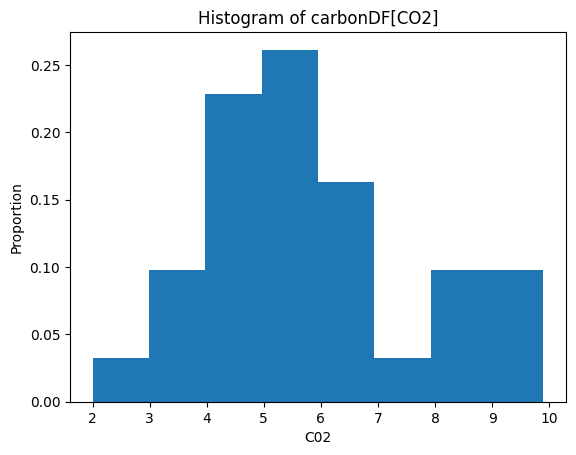

In [48]:
plt.hist(carbon['CO2'], density=True, bins=8)
plt.ylabel('Proportion')
plt.xlabel('C02')
plt.title('Histogram of carbonDF[CO2]');

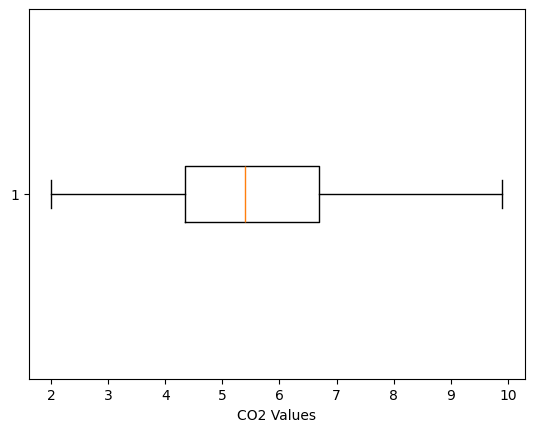

In [49]:
fig1, ax1 = plt.subplots()
plt.xlabel('CO2 Values')
ax1.boxplot(carbon['CO2'], vert=False);

In [50]:
crime = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Murder2.dat', sep='\s+')
crime.groupby('nation')['murder'].describe()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9784\3762639891.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  crime = pd.read_csv('https://stat4ds.rwth-aachen.de/data/Murder2.dat', sep='\s+')


,count,mean,std,min,25%,50%,75%,max
nation,,,,,,,,
Canada,10.0,1.673000,1.184437,0.0,1.03,1.735,1.875,4.07
US,51.0,5.252941,3.725391,1.0,2.65,5.000,6.450,24.20


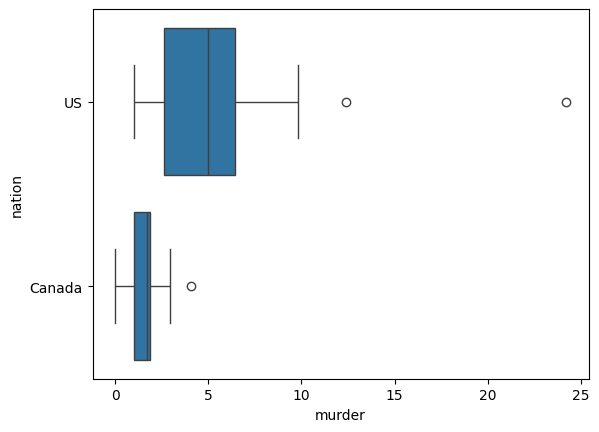

In [51]:
sns.boxplot(x='murder', y='nation', data=crime, orient='h');

## Descriptive Statistics for Bivariate Quantitative Data

In [52]:
gs = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Guns_Suicide.dat', sep='\s+')
gs.info()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9784\3149589098.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  gs = pd.read_csv('http://stat4ds.rwth-aachen.de/data/Guns_Suicide.dat', sep='\s+')


<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   state    51 non-null     str    
 1   guns     51 non-null     float64
 2   suicide  51 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.4 KB


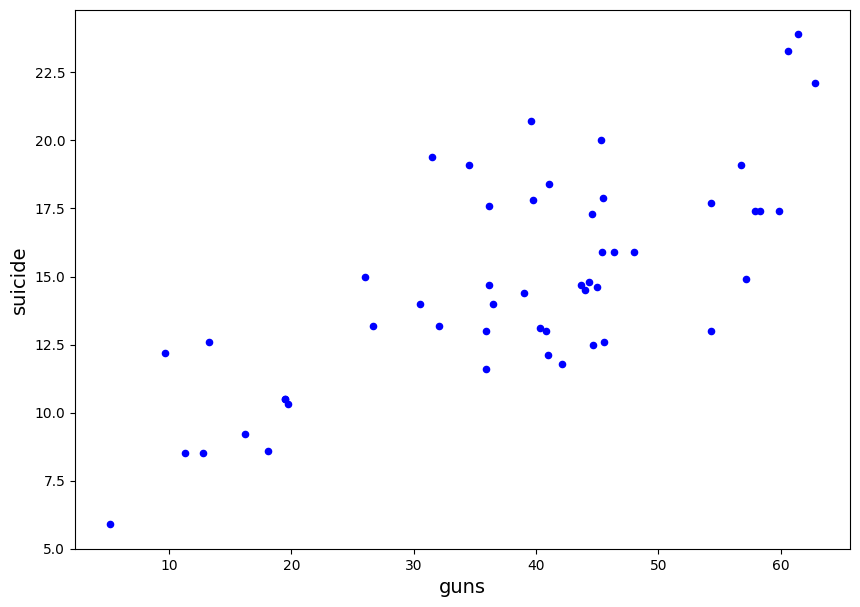

In [53]:
gs.plot(kind='scatter', x='guns', y='suicide', color='blue', figsize=(10, 7))
plt.xlabel('guns', size=14)
plt.ylabel('suicide', size=14)
plt.show()

In [54]:
corr_guns = gs.corr(numeric_only=True)

In [55]:
corr_guns

,guns,suicide
guns,1.000000,0.738667
suicide,0.738667,1.000000


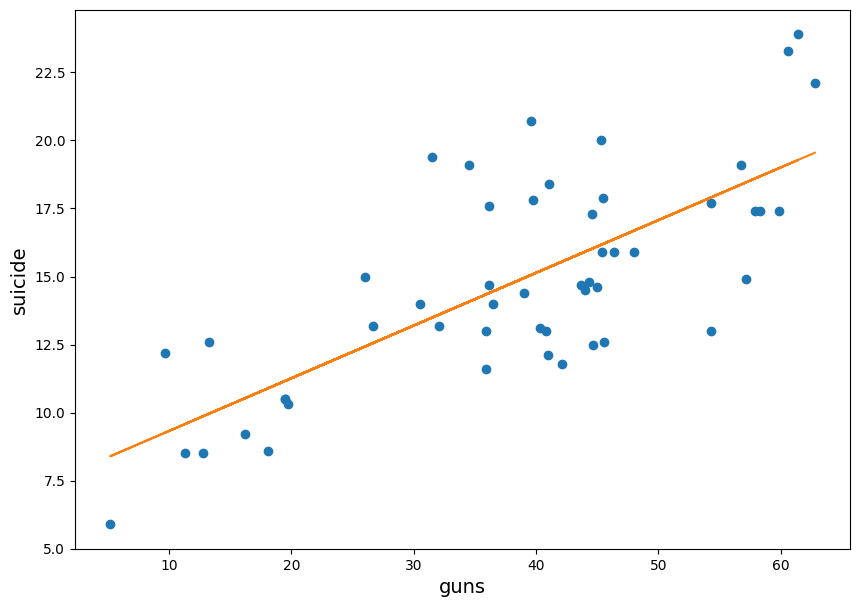

In [56]:
coef = np.polyfit(gs['guns'], gs['suicide'], 1)
LR_fn = np.poly1d(coef)

fig = plt.figure(figsize=(10, 7))
plt.plot(gs['guns'], gs['suicide'], 'o', gs['guns'], LR_fn(gs['guns']))
plt.xlabel('guns', size=14)
plt.ylabel('suicide', size=14);

In [57]:
import statsmodels.formula.api as sm
mod = sm.ols(formula='suicide ~ guns', data=gs).fit()
print(mod.params)

Intercept    7.390080
guns         0.193565
dtype: float64


In [58]:
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                suicide   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     58.84
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           6.11e-10
Time:                        09:00:40   Log-Likelihood:                -121.12
No. Observations:                  51   AIC:                             246.2
Df Residuals:                      49   BIC:                             250.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3901      1.037      7.125      0.0

In [59]:
print(mod.summary2())

                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.536   
Dependent Variable: suicide          AIC:                246.2471
Date:               2026-07-02 09:00 BIC:                250.1107
No. Observations:   51               Log-Likelihood:     -121.12 
Df Model:           1                F-statistic:        58.84   
Df Residuals:       49               Prob (F-statistic): 6.11e-10
R-squared:          0.546            Scale:              7.0433  
-------------------------------------------------------------------
              Coef.    Std.Err.     t      P>|t|    [0.025   0.975]
-------------------------------------------------------------------
Intercept     7.3901     1.0372   7.1253   0.0000   5.3058   9.4743
guns          0.1936     0.0252   7.6708   0.0000   0.1429   0.2443
-----------------------------------------------------------------
Omnibus:              2.959        Durbin-Watson:           2.314
Prob(Omnibus):   

## Descriptive Statistics for Bivariate Categorical Data

In [60]:
PID = pd.read_csv('http://stat4ds.rwth-aachen.de/data/PartyID.dat', sep='\s+')
PID.head()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9784\3661885506.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  PID = pd.read_csv('http://stat4ds.rwth-aachen.de/data/PartyID.dat', sep='\s+')


,race,id
0,white,Democrat
1,white,Democrat
2,white,Democrat
3,white,Democrat
4,white,Democrat


In [61]:
PID_table = pd.crosstab(PID['race'], PID['id'], margins=False)
PID_table

id,Democrat,Independent,Republican
race,,,
black,281,65,30
other,124,77,52
white,633,272,704


In [62]:
mr, mc = margins(PID_table)

In [63]:
print(mr)

[[ 376]
 [ 253]
 [1609]]


In [64]:
print(mc)

[[1038  414  786]]


In [65]:
PID.id.unique()

<ArrowStringArray>
['Democrat', 'Independent', 'Republican']
Length: 3, dtype: str

In [66]:
PID.race.unique()

<ArrowStringArray>
['white', 'black', 'other']
Length: 3, dtype: str

In [67]:
asarray = np.array(PID_table)/sum(sum(np.array(PID_table)))

probtable = pd.DataFrame(asarray, columns=['Democrat', 'Independent','Republican'])
probtable.index = ['black', 'white', 'other']
probtable

,Democrat,Independent,Republican
black,0.125559,0.029044,0.013405
white,0.055407,0.034406,0.023235
other,0.282842,0.121537,0.314567


In [68]:
asarray1 = np.array(PID_table)/mr 
probtable1 = pd.DataFrame(asarray1, columns=['Democrat', 'Independent','Republican'])
probtable1.index = ['black', 'white', 'other']
probtable1

,Democrat,Independent,Republican
black,0.747340,0.172872,0.079787
white,0.490119,0.304348,0.205534
other,0.393412,0.169049,0.437539


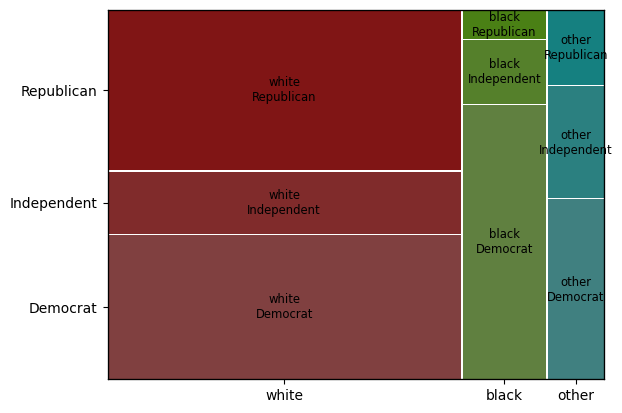

In [72]:
import statsmodels.api as sm
PIDtable = sm.stats.Table.from_data(PID)

fig, _ = mosaic(PID, index=['race', 'id'])

## Simulating Samples from a Bell-Shaped Population

In [ ]:
mu, sigma = 100, 16

(array([5., 7., 6., 8., 3., 1.]),
 array([ 70.52717488,  80.88496509,  91.24275531, 101.60054552,
        111.95833573, 122.31612594, 132.67391616]),
 <BarContainer object of 6 artists>)

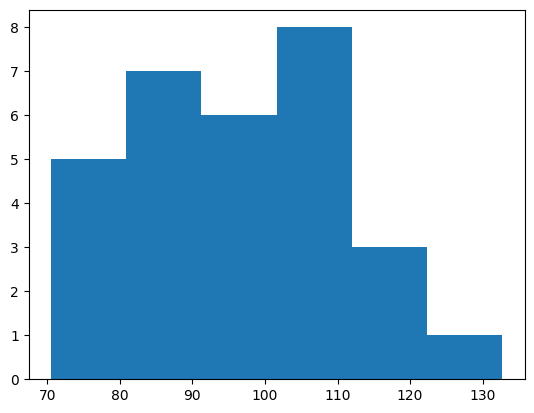

In [ ]:
y1 = np.random.normal(mu, sigma, 30)

y1.mean(), y1.std()

plt.hist(y1, bins='auto')

(array([ 5.,  6., 17., 17., 30., 47., 37., 41., 33., 33., 20.,  6.,  5.,
         3.]),
 array([ 58.87007488,  64.9375122 ,  71.00494952,  77.07238685,
         83.13982417,  89.20726149,  95.27469881, 101.34213613,
        107.40957345, 113.47701077, 119.54444809, 125.61188542,
        131.67932274, 137.74676006, 143.81419738]),
 <BarContainer object of 14 artists>)

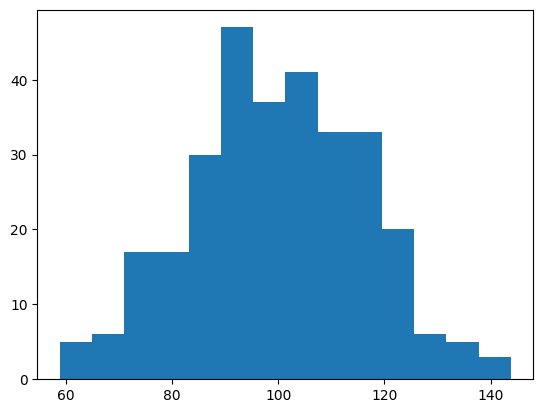

In [ ]:
y2 = np.random.normal(mu, sigma, 300)

y2.mean(), y2.std()

plt.hist(y2, bins='auto')